# HERMES-Studie: Symbole des Weiblichen? Zur Datenqualität einer kulturhistorischen Sammlung von Figurinen

Mit Unterstützung der HERMES-Forschungsförderung soll der Korpus von Objektdaten der ursprünglichen Privatsammlung „Symbole des Weiblichen“ des Göttinger Professors für Frauenheilkunde und Geburtshilfe Heinz Kirchhoff (1905-1997), die meist weiblich gelesene Darstellungen von der Altsteinzeit bis zur Moderne enthält, analysiert werden. Die Metadaten der Objekte sind komplett in der Museumsdatenbank kuniweb erschlossen, und mittels deskriptiver und explorativer Datenanalysen soll dazu beigetragen werden, den Bestand hinsichtlich der Qualität seiner Erschließung besser zu verstehen und Potenziale und Fragestellungen aufzuzeigen. Dem 2025 stattfindenden Seminar „Symbole des Weiblichen? Aufarbeitung einer besonderen Sammlung“ von Dr. Janne Arp-Neumann werden diese und weitere Visualisierungen zur Verfügung gestellt. Im Rahmen des Seminars werden zentrale Bestände der Sammlung aus den Perspektiven unterschiedlicher Fachdisziplinen (v.a. Ur- und Frühgeschichte, Ägyptologie, Ethnologie und Kulturanthropologie) beforscht sowie die Ergebnisse in die Objektdaten eingearbeitet. Die Veränderungen in den Daten als Resultat der Seminararbeit sollen am Ende sichtbar gemacht werden. Dies ermöglicht es den Teilnehmenden, die Auswirkungen ihrer Datenkuratierung zu reflektieren und auch zukünftig datenanalytische Fragestellungen mitzuberücksichtigen.

Die Kirchhoff-Sammlung online: https://sammlungen.uni-goettingen.de/sammlung/slg_1003/

**Dank an:** Dr.Janne-Arp-Neumann, Karsten Heck, Christian Mahnke, Jana Felizitas Schulz Funding: Dieses Projekt wurde durch das BMFTR-Datenkompetenzzentrum HERMES gefördert.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import json

C:\Users\Anna\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Daten:
#vor dem Seminar
df = pd.read_csv(r"kirchhoffdata_v1.csv", sep=',', encoding='utf-8')

#nach dem Seminar
#df = pd.read_csv(r"kirchhoffdata_v2.csv", sep=',', encoding='utf-8')

# erster Analyse-Zyklus

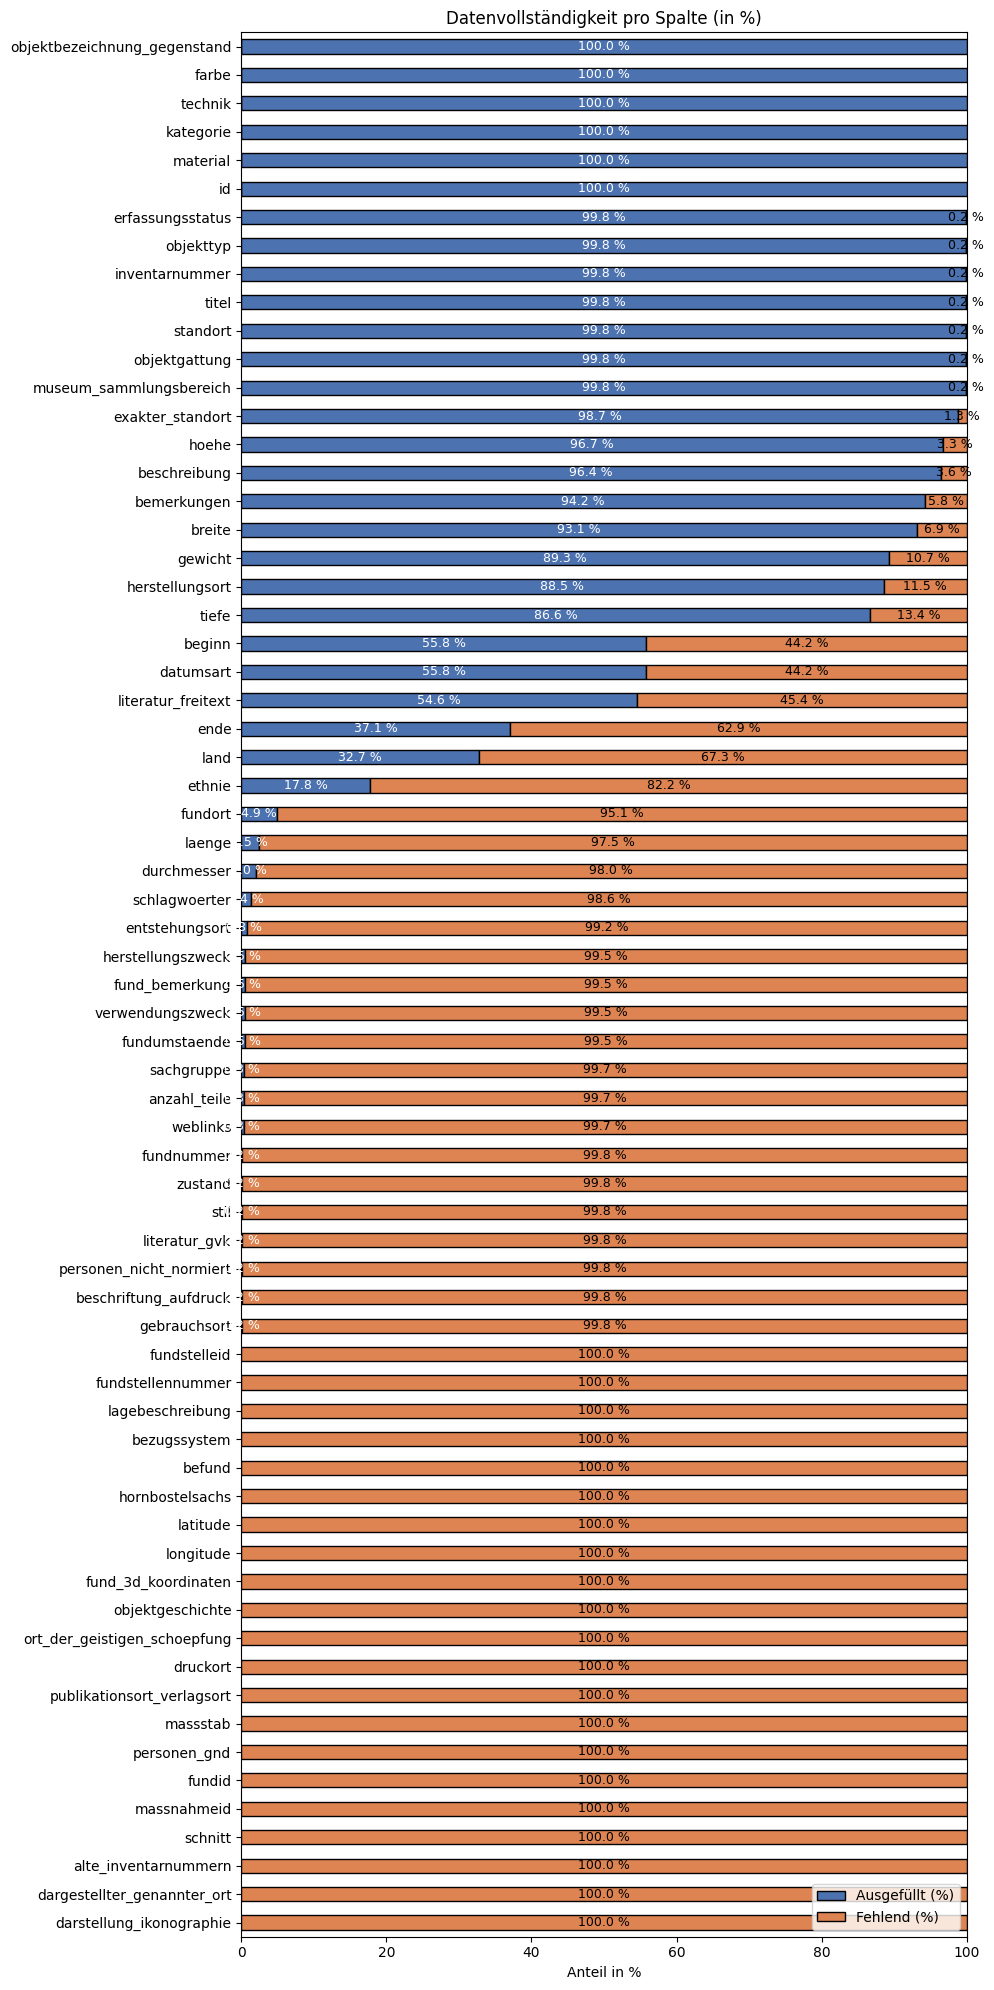

In [20]:
# Datenqualität
# Leere Strings als fehlend behandeln
df = df.replace('', pd.NA)
total_rows = len(df)
missing_pct = df.isna().sum() / total_rows * 100
filled_pct = 100 - missing_pct

quality_pct = pd.DataFrame({
    'Ausgefüllt (%)': filled_pct,
    'Fehlend (%)': missing_pct
})

# Nach Anteil fehlender Werte
quality_pct = quality_pct.sort_values(by='Fehlend (%)', ascending=False)
fig, ax = plt.subplots(figsize=(10, 20))

quality_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#4C72B0', '#DD8452'],
    edgecolor='black'
)

ax.set_xlabel('Anteil in %')
ax.set_ylabel('')
ax.set_title('Datenvollständigkeit pro Spalte (in %)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')

plt.tight_layout()
for i, (filled, missing) in enumerate(
    zip(quality_pct['Ausgefüllt (%)'], quality_pct['Fehlend (%)'])
):
    if filled > 0:
        ax.text(
            filled / 2,
            i,
            f"{filled:.1f} %",
            va='center',
            ha='center',
            color='white',
            fontsize=9
        )
    if missing > 0:
        ax.text(
            filled + missing / 2,
            i,
            f"{missing:.1f} %",
            va='center',
            ha='center',
            fontsize=9
        )
#plt.savefig("datenvollständigkeit.jpg", dpi=300)
plt.show()

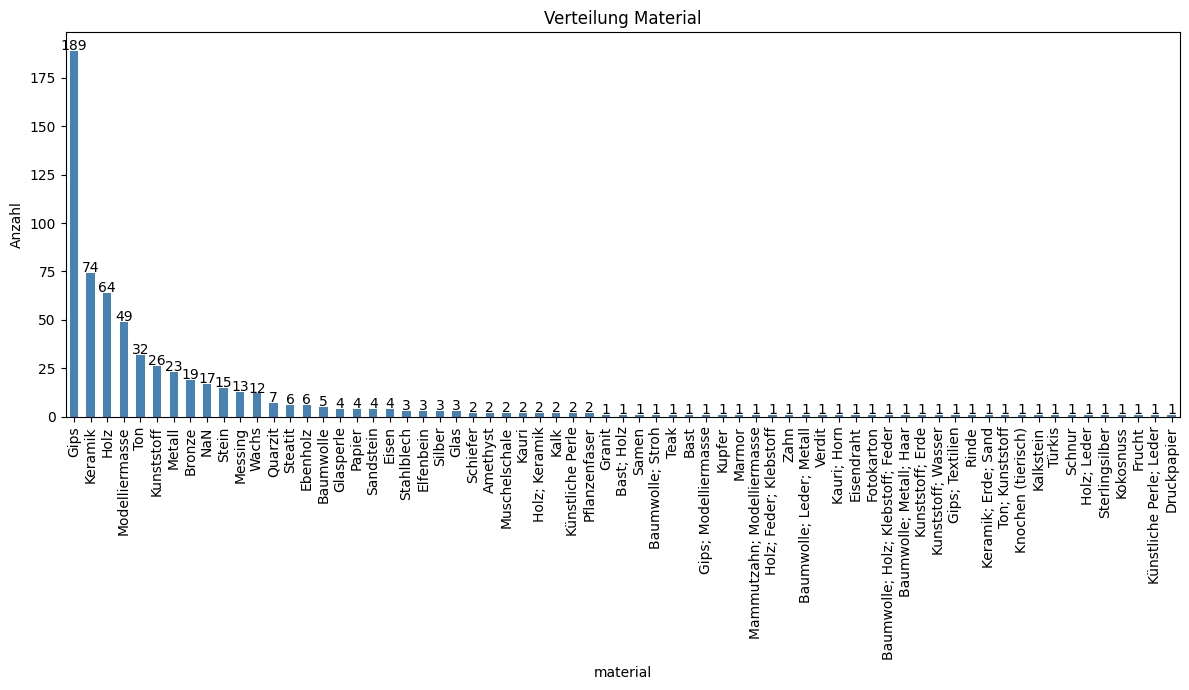

In [3]:
# Material BARPLOT

# Leere Werte und None-Werte durch 'Unbekannt' ersetzen
df['material'] = df['material'].fillna('NaN')
df['material'] = df['material'].replace('', 'NaN')

# Absolute Häufigkeit der Materialien zählen
category_counts = df['material'].dropna().value_counts()

# Diagramm
ax = category_counts.plot.bar(figsize=(12, 7), color='steelblue')
plt.title('Verteilung Material')
for i, v in enumerate(category_counts.values):  
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10)
    
plt.ylabel('Anzahl')
plt.xlabel('material')
plt.xticks(rotation=90)
plt.tight_layout()
#plt.savefig('kirchhoff_material.jpg', format='jpg')
plt.show()

In [15]:
# Pie-Chart-Funktion
def pie_with_other(df, column, label, threshold=1.0, figsize=(15, 10), cmap=plt.cm.tab20c, save=True):
    # Bereinigung
    series = (df[column].replace('', pd.NA).fillna('(NaN)'))

    # Häufigkeiten
    counts = series.value_counts()
    percent = counts / counts.sum() * 100

    main = percent[percent >= threshold]
    small = percent[percent < threshold]

    # Plot-Daten
    plot_data = main.copy()
    if not small.empty:
        plot_data[f'Sonstige (<{threshold}%)'] = small.sum()

    # Plot
    plt.figure(figsize=figsize)
    plot_data.sort_values(ascending=False).plot.pie(autopct='%1.1f%%', startangle=40, colors=plt.cm.tab20c.colors)

    plt.title(label)
    plt.ylabel('')
    plt.xlabel('')

    #if save:
     #   filename = f"{column}_pie.jpg"
      #  plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    # Kleine Kategorien ausgeben
    if not small.empty:
        print(f"\n{label} – zusammengefasste Kategorien (< {threshold} %):\n")
        for name, value in small.sort_values(ascending=False).items():
            print(f"{name}; {counts[name]} Objekte; {value:.2f} %")

In [18]:
# relevante Spalten für Pie-Charts

COLUMNS = [
    {
        "column": "objektbezeichnung_gegenstand",
        "label": "Objektbezeichnung Gegenstand",
        "threshold": 1.0
    },
    {
        "column": "farbe",
        "label": "Farbe der Objekte",
        "threshold": 1.0
    },
    {
        "column": "kategorie",
        "label": "Objektkategorie",
        "threshold": 1.0
    },
    {
        "column": "objektgattung",
        "label": "Objektgattung",
        "threshold": 1
    },
    {
        "column": "technik",
        "label": "Technik",
        "threshold": 1.0
    },
      {
        "column": "stil",
        "label": "Stil",
        "threshold": 1.0
    },
    {
        "column": "ethnie",
        "label": "Ethnie",
        "threshold": 1.0
    },
    {
        "column": "erfassungsstatus",
        "label": "Erfassungsstatus",
        "threshold": 1.0
    },
    {
        "column": "herstellungsort",
        "label": "Herstellungsort",
        "threshold": 1.0
    }
]

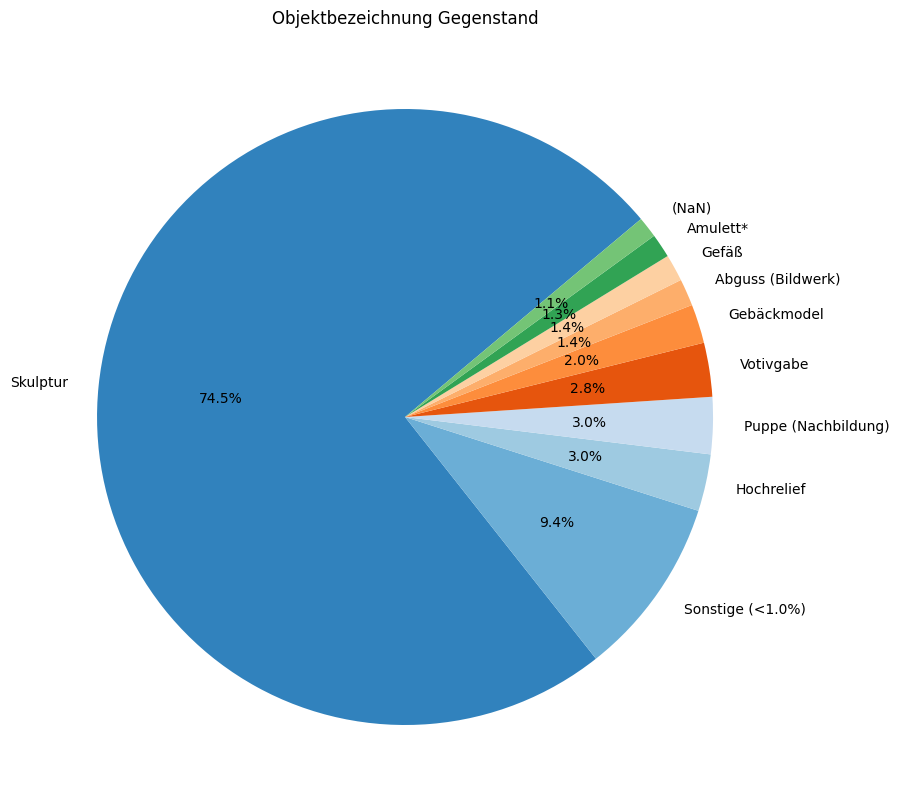


Objektbezeichnung Gegenstand – zusammengefasste Kategorien (< 1.0 %):

Fossil, Präparat, menschliche, tierische und pflanzliche Überreste*; 6 Objekte; 0.94 %
Münze, Medaille, Zahlungsmittel*; 4 Objekte; 0.63 %
Öllampe; 3 Objekte; 0.47 %
Plastik (Bildwerk); 3 Objekte; 0.47 %
Nahrungsmittel, Genussmittel, Futtermittel*; 3 Objekte; 0.47 %
Kette, Anhänger*; 3 Objekte; 0.47 %
Vogelei; 3 Objekte; 0.47 %
Halskette (Schmuck); 2 Objekte; 0.31 %
Halbrelief; 2 Objekte; 0.31 %
Bildwerk; 2 Objekte; 0.31 %
Krug; 2 Objekte; 0.31 %
Vase; 2 Objekte; 0.31 %
Maske; 2 Objekte; 0.31 %
Gesichtsmaske; 2 Objekte; 0.31 %
Medaille; 2 Objekte; 0.31 %
Matrize (Prägeform); 2 Objekte; 0.31 %
Flasche; 2 Objekte; 0.31 %
Brett; 2 Objekte; 0.31 %
Gestell (Möbel)*; 2 Objekte; 0.31 %
Vorratstopf; 1 Objekte; 0.16 %
Römische Münze; 1 Objekte; 0.16 %
Gussform; 1 Objekte; 0.16 %
Löffel (Besteck); 1 Objekte; 0.16 %
Schale; 1 Objekte; 0.16 %
Relief; 1 Objekte; 0.16 %
Siebdruck; 1 Objekte; 0.16 %
Kupferstich; 1 Objekte; 0.16 %

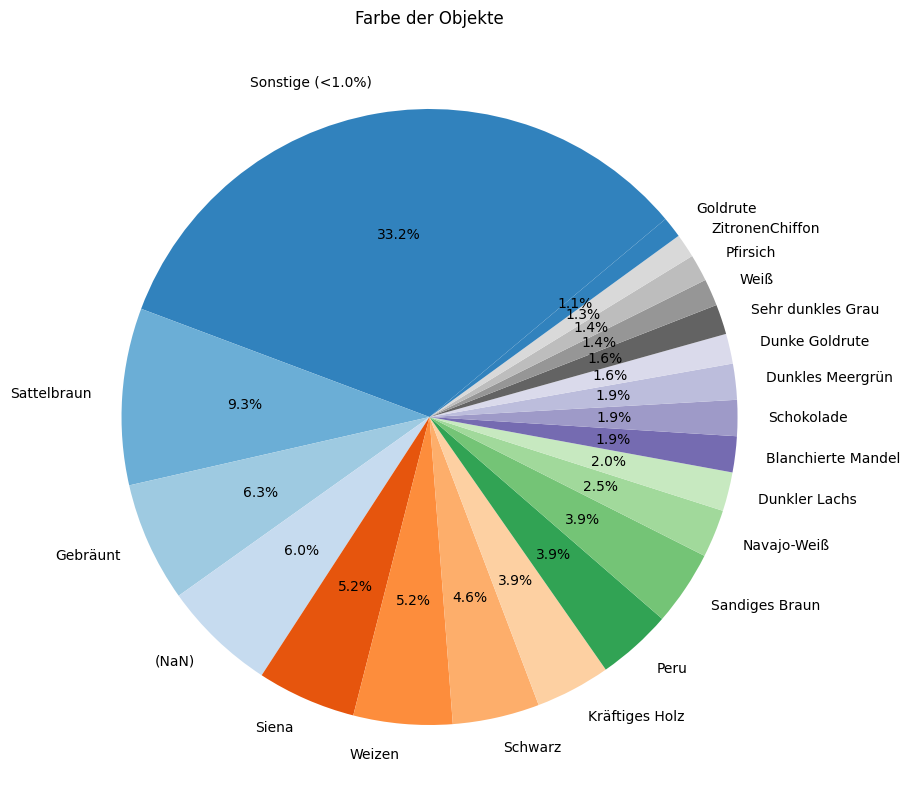


Farbe der Objekte – zusammengefasste Kategorien (< 1.0 %):

Schwarz; Sattelbraun; 6 Objekte; 0.94 %
Schiefergrau; 6 Objekte; 0.94 %
Antikweiß; 6 Objekte; 0.94 %
Rosa-Braun; 6 Objekte; 0.94 %
Meergrün; Schwarz; 6 Objekte; 0.94 %
Papaya; 5 Objekte; 0.79 %
Silber; 5 Objekte; 0.79 %
Meergrün; 5 Objekte; 0.79 %
Mokassin; 5 Objekte; 0.79 %
Biskuit; 5 Objekte; 0.79 %
Dunkles Olivengrün; 4 Objekte; 0.63 %
Tomate; 4 Objekte; 0.63 %
Braun; 4 Objekte; 0.63 %
Vergilbte Spitze; 4 Objekte; 0.63 %
Getreide; 4 Objekte; 0.63 %
Türkis; 3 Objekte; 0.47 %
Schwarz; Weiß; 3 Objekte; 0.47 %
Helles Grau; 3 Objekte; 0.47 %
Schiefergrau; Schwarz; 3 Objekte; 0.47 %
Olivbraun; 3 Objekte; 0.47 %
Dunkleres Grau; 3 Objekte; 0.47 %
Meergrün; Dunke Goldrute; 2 Objekte; 0.31 %
Orange; 2 Objekte; 0.31 %
Indischrot; 2 Objekte; 0.31 %
Heller Lachs; Tomate; 2 Objekte; 0.31 %
Heller Lachs; 2 Objekte; 0.31 %
Gebräunt; Schokolade; 2 Objekte; 0.31 %
Royalblau; Peru; 2 Objekte; 0.31 %
Purpur; Sattelbraun; 2 Objekte; 0.31 %
Hel

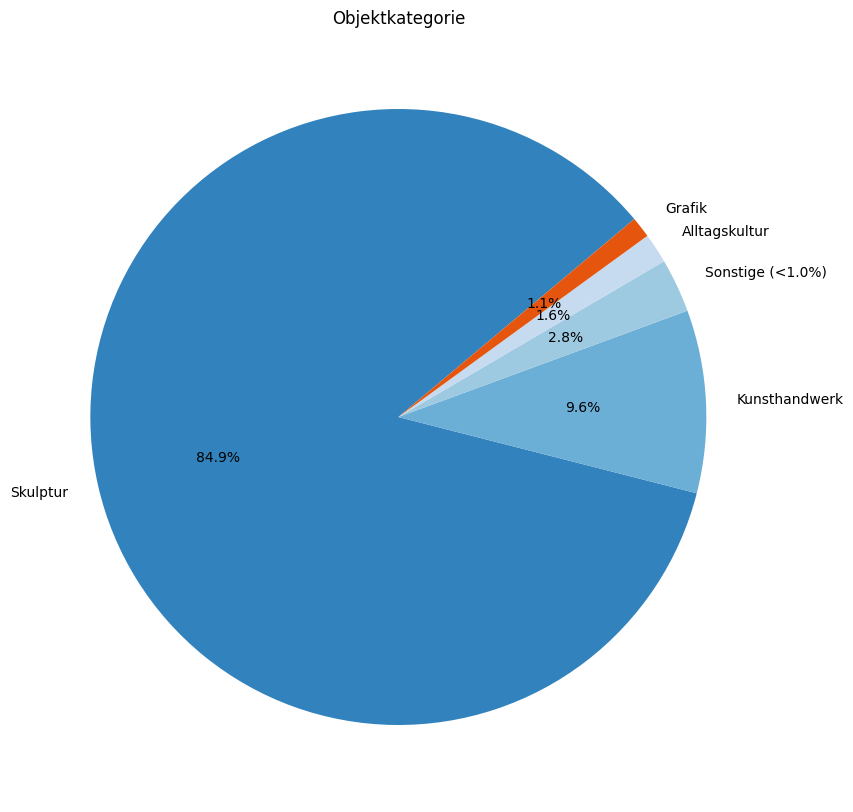


Objektkategorie – zusammengefasste Kategorien (< 1.0 %):

Naturkunde; 6 Objekte; 0.94 %
Malerei; 4 Objekte; 0.63 %
Münzen, Medaillen, Geldscheine; 3 Objekte; 0.47 %
Archäologie; 2 Objekte; 0.31 %
(NaN); 1 Objekte; 0.16 %
Ethnologie; 1 Objekte; 0.16 %
Druckschriften; 1 Objekte; 0.16 %


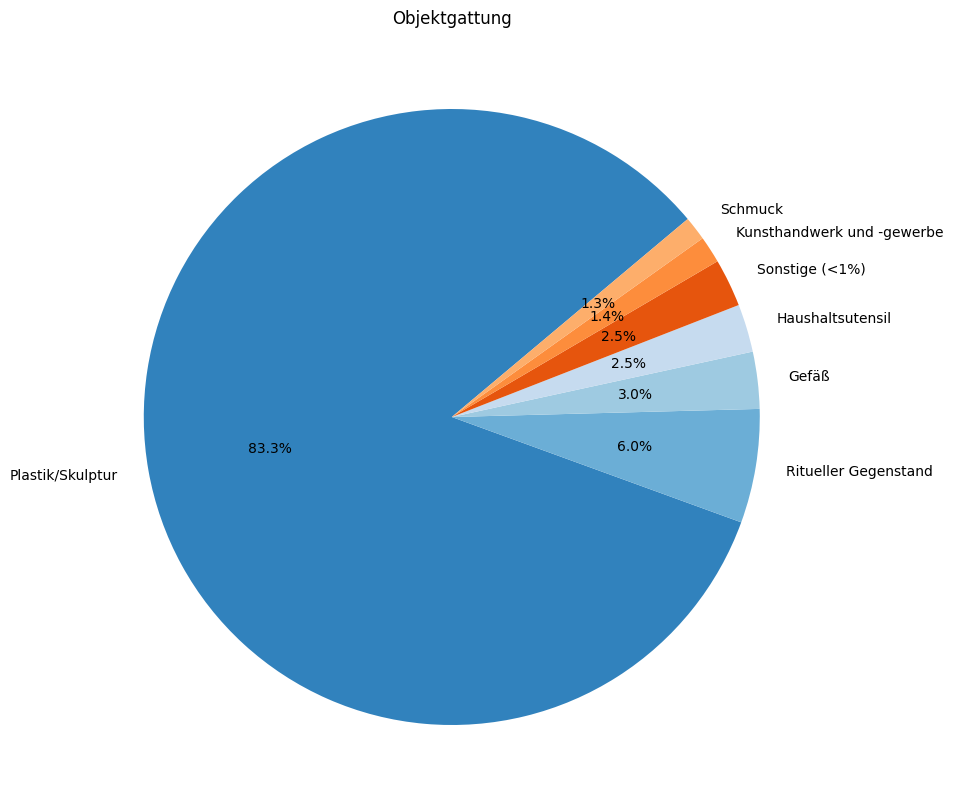


Objektgattung – zusammengefasste Kategorien (< 1 %):

Grafik; 4 Objekte; 0.63 %
Kleidung und Accessoire; 3 Objekte; 0.47 %
Malerei; 2 Objekte; 0.31 %
Münze/Medaille; 2 Objekte; 0.31 %
Ehr- und Abzeichen; 2 Objekte; 0.31 %
Modell; 1 Objekte; 0.16 %
Werkzeug; 1 Objekte; 0.16 %
(NaN); 1 Objekte; 0.16 %


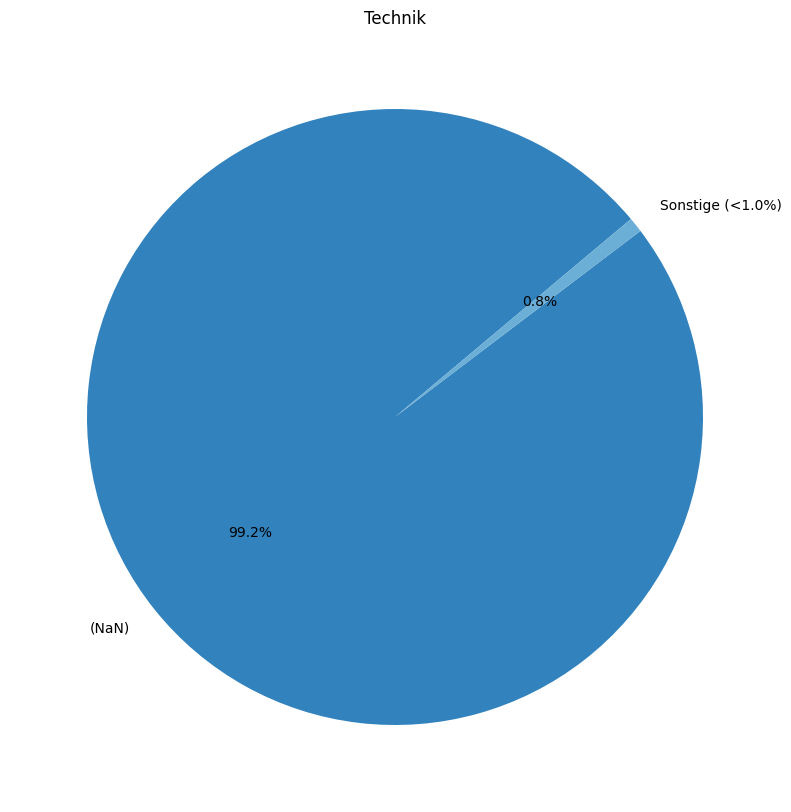


Technik – zusammengefasste Kategorien (< 1.0 %):

gestanzt; 2 Objekte; 0.31 %
Druckverfahren; 2 Objekte; 0.31 %
Aufzeichnung; 1 Objekte; 0.16 %


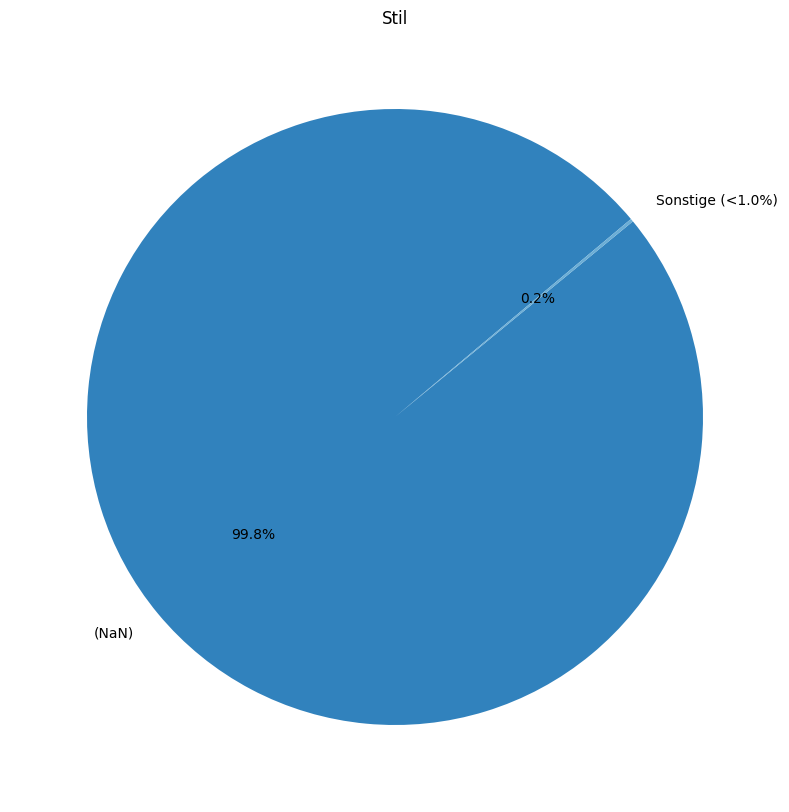


Stil – zusammengefasste Kategorien (< 1.0 %):

Paläolithikum; 1 Objekte; 0.16 %


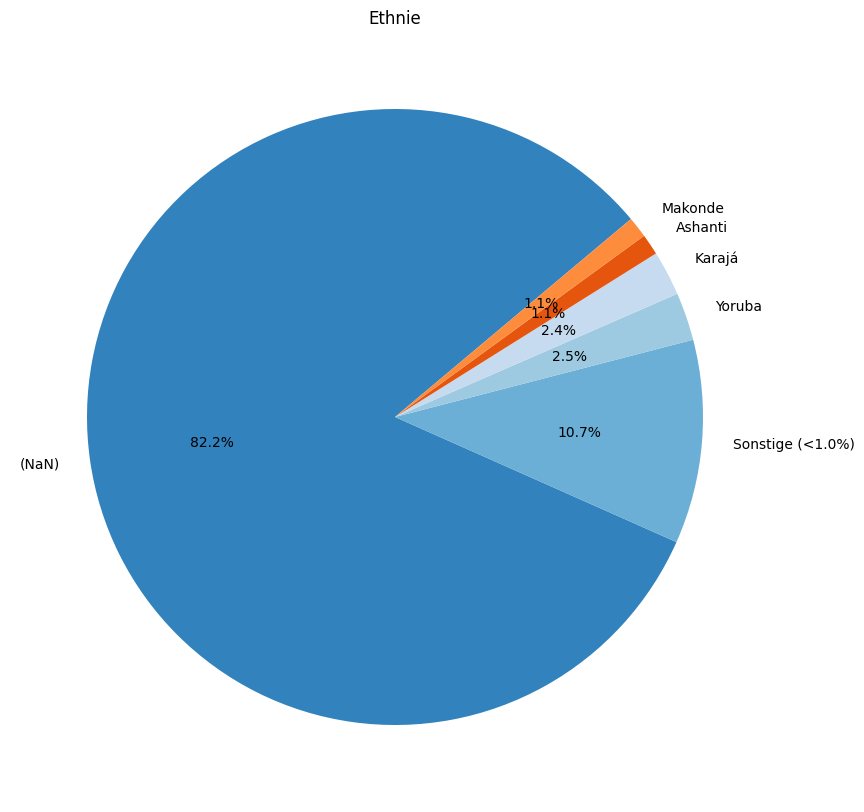


Ethnie – zusammengefasste Kategorien (< 1.0 %):

Inka; 6 Objekte; 0.94 %
Ewe; 5 Objekte; 0.79 %
Azteken; 5 Objekte; 0.79 %
Baule; 4 Objekte; 0.63 %
Iatmul; 3 Objekte; 0.47 %
Tikuna; 3 Objekte; 0.47 %
Turkana; 3 Objekte; 0.47 %
Mochica; 3 Objekte; 0.47 %
Kissi; 3 Objekte; 0.47 %
Shona; 3 Objekte; 0.47 %
Maori; 2 Objekte; 0.31 %
Fon; 2 Objekte; 0.31 %
Hopi; 2 Objekte; 0.31 %
Abelam; 2 Objekte; 0.31 %
Fanti; 2 Objekte; 0.31 %
Kwere; 2 Objekte; 0.31 %
Be-Kuba; 1 Objekte; 0.16 %
Quimbaya; 1 Objekte; 0.16 %
Dogon; 1 Objekte; 0.16 %
Luba; 1 Objekte; 0.16 %
Batshokwe; 1 Objekte; 0.16 %
Olmeken; 1 Objekte; 0.16 %
Germanisch; 1 Objekte; 0.16 %
Inuit; 1 Objekte; 0.16 %
Bangwa; 1 Objekte; 0.16 %
Mossi; 1 Objekte; 0.16 %
Dajak; 1 Objekte; 0.16 %
Herero; 1 Objekte; 0.16 %
Khmer; 1 Objekte; 0.16 %
Maya; 1 Objekte; 0.16 %
Basonge; 1 Objekte; 0.16 %
Kopten; 1 Objekte; 0.16 %
Fulbe; 1 Objekte; 0.16 %
Zaramo und Kevere; 1 Objekte; 0.16 %


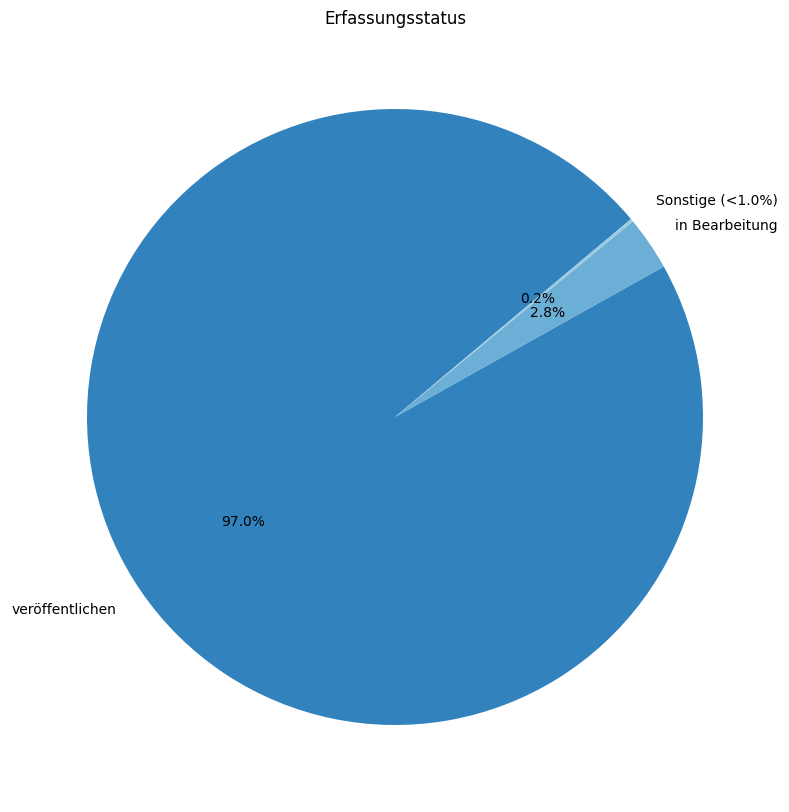


Erfassungsstatus – zusammengefasste Kategorien (< 1.0 %):

(NaN); 1 Objekte; 0.16 %


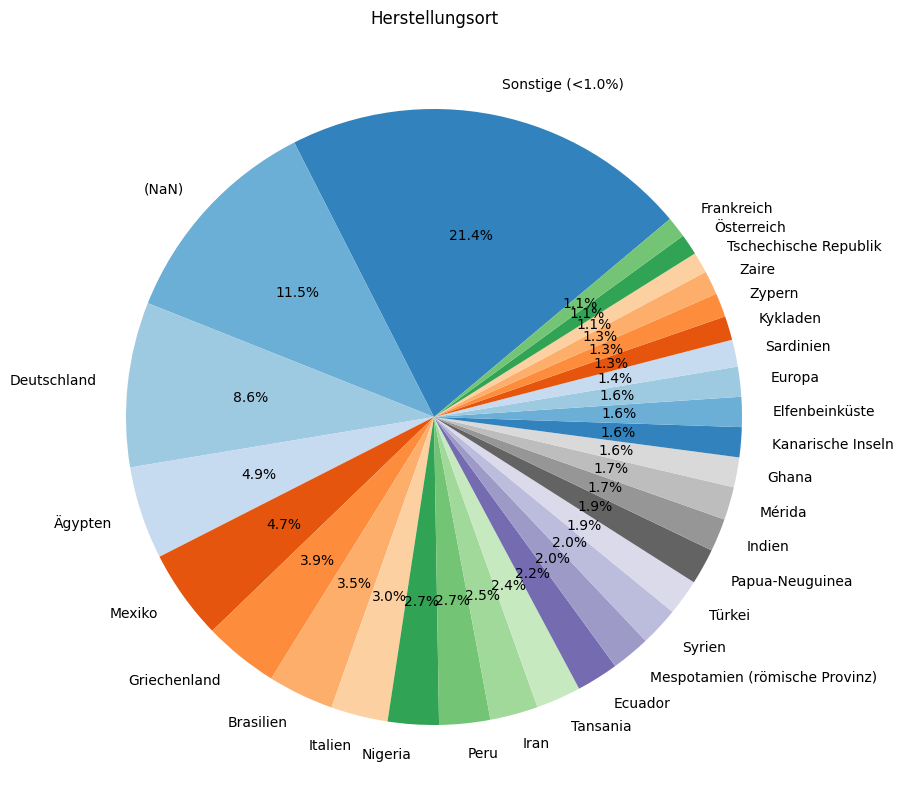


Herstellungsort – zusammengefasste Kategorien (< 1.0 %):

Gönnersdorf; 6 Objekte; 0.94 %
Israel; 6 Objekte; 0.94 %
Anatolia; 6 Objekte; 0.94 %
Philippinen; 5 Objekte; 0.79 %
Simbabwe; 5 Objekte; 0.79 %
Togo; 5 Objekte; 0.79 %
Amphoe Sawankhalok; 5 Objekte; 0.79 %
Volksrepublik China; 4 Objekte; 0.63 %
Thailand; 4 Objekte; 0.63 %
Benin; 4 Objekte; 0.63 %
Russland; 4 Objekte; 0.63 %
Malta; 4 Objekte; 0.63 %
Bali; 4 Objekte; 0.63 %
Ukraine; 3 Objekte; 0.47 %
Tall Ḩalaf; 3 Objekte; 0.47 %
Kamerun; 3 Objekte; 0.47 %
Sierra Leone; 3 Objekte; 0.47 %
Afrika; 3 Objekte; 0.47 %
Japan; 3 Objekte; 0.47 %
Rumänien; 2 Objekte; 0.31 %
Kolumbien; 2 Objekte; 0.31 %
Köln; 2 Objekte; 0.31 %
Schweiz; 2 Objekte; 0.31 %
Portugal; 2 Objekte; 0.31 %
Hawaii; 2 Objekte; 0.31 %
Kreta; 2 Objekte; 0.31 %
Arizona; 2 Objekte; 0.31 %
Neuseeland; 2 Objekte; 0.31 %
Kambodscha; 2 Objekte; 0.31 %
Göttingen; 2 Objekte; 0.31 %
Luxor; 1 Objekte; 0.16 %
Venezuela; 1 Objekte; 0.16 %
Mali; 1 Objekte; 0.16 %
Republik Südafrika

In [19]:
# Visualisierungen
for cfg in COLUMNS:
    pie_with_other(
        df=df,
        column=cfg["column"],
        label=cfg["label"],
        threshold=cfg["threshold"]
    )

In [ ]:
# Zeitstrahl Jahre

df['beginn'] = pd.to_numeric(df['beginn'], errors='coerce')
jahre = df['beginn'].dropna().astype(int)
jahr_counts = jahre.value_counts().sort_index()

print(f"Anzahl gefundener Jahreswerte: {len(jahr_counts)}

plt.figure(figsize=(6, 20))
plt.barh(jahr_counts.index.astype(str), jahr_counts.values)

for i, v in enumerate(jahr_counts.values):
    plt.text(v + 0.2, i, str(v), va='center', fontsize=8)

plt.xlabel("Anzahl Objekte")
plt.ylabel("Jahr (inkl. v. Chr.)")
plt.title("Verteilung der Objekte nach Jahr")
plt.tight_layout()
#plt.savefig('t1_kategorie_objektdatierung-jahr2.jpg', format='jpg')  # Speichern als JPG
plt.show()

In [ ]:
# Zeitstrahl Jahrhunderte

# Jahreswerte bereinigen
df['beginn'] = pd.to_numeric(df['beginn'], errors='coerce')
jahre = df['beginn'].dropna().astype(int)

# Jahrhundert-Funktion
def jahr_zu_jahrhundert(jahr):
    if jahr > 0:
        return (jahr - 1) // 100 + 1
    else:
        return -((abs(jahr) - 1) // 100 + 1)

# Jahrhunderte berechnen
df_jahrhunderte = jahre.apply(jahr_zu_jahrhundert)

# Häufigkeiten zählen und sortieren
jahrhundert_counts = df_jahrhunderte.value_counts().sort_index()

print(f"Anzahl unterschiedlicher Jahrhunderte: {len(jahrhundert_counts)}")

# labels
labels = [
    f"{abs(jh)}. Jh. v. Chr." if jh < 0 else f"{jh}. Jh. n. Chr."
    for jh in jahrhundert_counts.index
]

# Plot
plt.figure(figsize=(6, 10))
plt.barh(labels, jahrhundert_counts.values)

for i, value in enumerate(jahrhundert_counts.values):
    plt.text(
        value + 0.5,
        i,
        str(value),
        va='center'
    )
    
plt.xlabel("Anzahl Objekte")
plt.ylabel("Jahrhundert")
plt.title("Verteilung der Objekte nach Jahrhunderten")
plt.tight_layout()
#plt.savefig("t1_objektdatierung_jahrhunderte.jpg", dpi=300)
plt.show()

In [ ]:
# Herstellungsort und zugehöriges Land Heatmap

# Leere Werte 'Unbekannt'
df['land'] = df['land'].fillna('NaN')  # Ersetzt NaN durch 'Unbekannt'
df['land'] = df['land'].replace('', 'NaN')  # Ersetzt leere Strings durch 'Unbekannt'

land_counts = df['land'].value_counts() # sortiere nach Anzahl der Nennungen
heatmap_data = pd.pivot_table(df, index='herstellungsort', columns='land', aggfunc='size', fill_value=0) # Pivot-Tabelle
heatmap_data = heatmap_data[land_counts.index] # nach Häufigkeit sortiert

# Heatmap
plt.figure(figsize=(10, 20))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='Blues')
plt.title('Häufigkeit von Herstellungsort und dem Objekt zugeordneten Land')
plt.xlabel('Land')
plt.ylabel('Herstellungsort')
plt.tight_layout()
#plt.savefig("herstellungsort_land.jpg", dpi=300)
plt.show()

In [ ]:
# exakter Standort und Kategorie
combo = df.groupby(['herstellungsort', 'kategorie']).size().unstack().fillna(0)

top_locations = df['herstellungsort'].value_counts().head(100).index # Filter to top100 locations
combo = combo.loc[top_locations]

plt.figure(figsize=(10, 20))
sns.heatmap(combo, annot=True, fmt='g', cmap='Blues')
plt.title('Häufigkeit von Kategorie nach Herstellungsort')
plt.xlabel('kategorie')
plt.ylabel('herstellungsort')
plt.tight_layout()
#plt.savefig('t1_kategorie_herstellungsort.jpg', format='jpg')  # Speichern als JPG
plt.show()

## Schlagwort und Wortfeldanalysen
Es müssen in diesem Zusammenhang die im Korpus genannten Termini verwendet und so leider reproduziert werden. Diese müssen aber in ihrem historisierenden Kontext verstanden werden und die Autorin distanziert sich von heteronormativem Othering, welches durch die Verwendung von „andere Geschlechter“ entstehen kann. Auf die Unterdrückung, die durch die anderen genannten Begriffe, die oft mit Biologismus und Pathologisierung verbunden wurden, ausgeübt wurde, soll ausdrücklich hingewiesen werden. Als Einstiegspunkt: Butler 1990, Stryker 2008.

In [ ]:
# Regex Funktionen

# Sätze finden
def find_sentences_with_keywords(text, pattern):
    if not isinstance(text, str):
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s for s in sentences if pattern.search(s)]

In [ ]:
# Keyword-Analysen FRAU
# Keywords / Ausschlüsse
keywords = ["Venus", "Frau", "Geburt", "Gebähr", "Schwangerschaft", "Mutterschaft", "Urmutter", "Vulva", "Vagina", "Scham", "Göttin", "weiblich", "weiblich", "Mater"]
exclude_words = ["Material", "Materialienmappe", "Materia", "Materialien"]
exclude_cols = ["museum_sammlungsbereich", "standort", "exakter_standort"]

# Keywords + Komposita
pattern = re.compile(r'(?:' + '|'.join(map(re.escape, keywords)) + r')\w*', flags=re.IGNORECASE)
# Ausschluss (Material* etc.)
pattern_exclude = re.compile(r'^(?:' + '|'.join(map(re.escape, exclude_words)) + r')', flags=re.IGNORECASE)

# Keyword-Suche
results = []

for _, row in df.iterrows():
    for col, value in row.items():

        if col in exclude_cols or not isinstance(value, str):
            continue

        sentences = find_sentences_with_keywords(value, pattern)

        for s in sentences:
            hits = re.findall(pattern, s)

            for hit in hits:
                # Ausschluss prüfen
                if pattern_exclude.match(hit):
                    continue

                results.append({
                    "id": row.get("id"),
                    "keyword": hit,
                    "gefundener_satz": s.strip(),
                    "untersuchte_spalte": col,
                    "kompletter_text": value
                })

# DataFrame & Auswertung
df_keywords = pd.DataFrame(results)

total_ids_in_df_keywords = df_keywords["id"].nunique()
print(f"Anzahl unterschiedlicher IDs in df_keywords: {total_ids_in_df_keywords}")
print(f"Anzahl der gefundenen Treffer: {len(df_keywords)}")

display(df_keywords.head(20))

# Keyword-Häufigkeiten
keyword_counts = (df_keywords["keyword"].value_counts().sort_values(ascending=False))

# Plot gesamte ZÄHLUNG
plt.figure(figsize=(30, 5))
bars = keyword_counts.plot.bar()

for i, v in enumerate(keyword_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.ylabel("Anzahl Nennungen")
plt.xlabel("Schlagwort (inkl. Komposita)")
plt.title("Häufigkeit der gefundenen Schlagwörter (Regex-basiert)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig('schlagwoerter_frau_gesamtzählung.jpg', format='jpg') 
plt.show()

# Plot: je nach Datensätzen
# Keyword → IDs
keyword_ids = {k: set() for k in keywords}
all_ids = set(df["id"])

for _, row in df.iterrows():
    for col, val in row.items():
        if col in exclude_cols or not isinstance(val, str):
            continue

        hits = re.findall(pattern, val)
        for hit in hits:
            if pattern_exclude.match(hit):
                continue
            base = next(
                (k for k in keywords if hit.lower().startswith(k.lower())),
                None
            )
            if base:
                keyword_ids[base].add(row["id"])

plot_df = pd.DataFrame({
    "Mit Keyword": {k: len(v) for k, v in keyword_ids.items()}
})
plot_df["Ohne Keyword"] = len(all_ids) - plot_df["Mit Keyword"]
plot_df = plot_df.sort_values("Mit Keyword", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(plot_df.index, plot_df["Mit Keyword"], label="Mit Keyword", color="#4C72B0")
plt.bar(
    plot_df.index,
    plot_df["Ohne Keyword"],
    bottom=plot_df["Mit Keyword"],
    label="Ohne Keyword",
    color="#DDDDDD"
)

for i, v in enumerate(plot_df["Mit Keyword"]):
    plt.text(i, v + 5, v, ha="center", fontsize=9)

plt.title("Datensätze mit / ohne Schlagwort (ID-basiert)")
plt.ylabel("Anzahl Datensätze")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
#plt.savefig('schlagwoerter_frau_ids.jpg', format='jpg') 
plt.show()

In [ ]:
# Keyword-Analysen ANDERE GESCHLECHTER
# Keywords / Ausschlüsse
keywords = ["Vater","männlich","Penis", "Hoden","Zwitter","androgyn","Hermaphrodit","Intersex","Zweigeschlechtlich","Doppeltgeschlechtlich","Sexualität","Geschlecht"]
exclude_words = ["Material", "Materialienmappe", "Materia", "Materialien"]
exclude_cols = ["museum_sammlungsbereich", "standort", "exakter_standort"]

# Keywords + Komposita
pattern = re.compile(r'(?:' + '|'.join(map(re.escape, keywords)) + r')\w*', flags=re.IGNORECASE)
# Ausschluss (Material* etc.)
pattern_exclude = re.compile(r'^(?:' + '|'.join(map(re.escape, exclude_words)) + r')', flags=re.IGNORECASE)

# Keyword-Suche
results = []

for _, row in df.iterrows():
    for col, value in row.items():

        if col in exclude_cols or not isinstance(value, str):
            continue

        sentences = find_sentences_with_keywords(value, pattern)

        for s in sentences:
            hits = re.findall(pattern, s)

            for hit in hits:
                # Ausschluss prüfen
                if pattern_exclude.match(hit):
                    continue

                results.append({
                    "id": row.get("id"),
                    "keyword": hit,
                    "gefundener_satz": s.strip(),
                    "untersuchte_spalte": col,
                    "kompletter_text": value
                })

# DataFrame & Auswertung
df_keywords = pd.DataFrame(results)

total_ids_in_df_keywords = df_keywords["id"].nunique()
print(f"Anzahl unterschiedlicher IDs in df_keywords: {total_ids_in_df_keywords}")
print(f"Anzahl der gefundenen Treffer: {len(df_keywords)}")

display(df_keywords.head(20))

# Keyword-Häufigkeiten
keyword_counts = (df_keywords["keyword"].value_counts().sort_values(ascending=False))

# Plot gesamte ZÄHLUNG
plt.figure(figsize=(15, 5))
bars = keyword_counts.plot.bar()
for i, v in enumerate(keyword_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.ylabel("Anzahl Nennungen")
plt.xlabel("Schlagwort (inkl. Komposita)")
plt.title("Häufigkeit der gefundenen Schlagwörter (Regex-basiert)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig('schlagwoerter_geschlechter_gesamtnennungen2.jpg', format='jpg') 
plt.show()

# Plot nach Datensätzen
keyword_ids = {k: set() for k in keywords}
all_ids = set(df["id"])

for _, row in df.iterrows():
    for col, val in row.items():
        if col in exclude_cols or not isinstance(val, str):
            continue

        hits = re.findall(pattern, val)
        for hit in hits:
            if pattern_exclude.match(hit):
                continue
            base = next(
                (k for k in keywords if hit.lower().startswith(k.lower())),
                None
            )
            if base:
                keyword_ids[base].add(row["id"])

# Plot-Daten
plot_df = pd.DataFrame({
    "Mit Keyword": {k: len(v) for k, v in keyword_ids.items()}
})
plot_df["Ohne Keyword"] = len(all_ids) - plot_df["Mit Keyword"]
plot_df = plot_df.sort_values("Mit Keyword", ascending=False)

# Plot
plt.figure(figsize=(8, 6))
plt.bar(plot_df.index, plot_df["Mit Keyword"], label="Mit Keyword", color="#4C72B0")
plt.bar(
    plot_df.index,
    plot_df["Ohne Keyword"],
    bottom=plot_df["Mit Keyword"],
    label="Ohne Keyword",
    color="#DDDDDD"
)

for i, v in enumerate(plot_df["Mit Keyword"]):
    plt.text(i, v + 5, v, ha="center", fontsize=9)

plt.title("Datensätze mit / ohne Schlagwort (ID-basiert)")
plt.ylabel("Anzahl Datensätze")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
#plt.savefig('schlagwoerter_geschlechter_ids2.jpg', format='jpg') 
plt.show()

In [ ]:
# total IDs mit Keywords
total_ids_in_df_keywords = df_keywords["id"].nunique()
print(f"Anzahl unterschiedlicher IDs in df_keywords: {total_ids_in_df_keywords}")

# Anzahl aller Regex-Treffer pro ID
hits_per_id = (
    df_keywords
    .groupby("id")
    .size()
    .sort_values(ascending=False)
)

print("Treffer pro ID (Top 10):")
print(hits_per_id.head(10))
plt.figure(figsize=(10, 4))
hits_per_id.head(20).plot.bar()
plt.ylabel("Anzahl Treffer")
plt.title("Anzahl der Regex-Treffer pro ID (Top 20)")
plt.tight_layout()
#plt.savefig('schlagwoerter_total_ids.jpg', format='jpg') 
plt.show()

In [ ]:
# andere Keywords

keywords = ["Hochzeit","Ursymbol","Brüste","Brust","Frucht","Fruchtbarkeit","Empfängnis","Zeugung"]
exclude_words = ["Material", "Materialienmappe", "Materia", "Materialien"]
exclude_cols = ["museum_sammlungsbereich", "standort", "exakter_standort"]

# Keywords + Komposita
pattern = re.compile(r'(?:' + '|'.join(map(re.escape, keywords)) + r')\w*', flags=re.IGNORECASE)
# Ausschluss (Material* etc.)
pattern_exclude = re.compile(r'^(?:' + '|'.join(map(re.escape, exclude_words)) + r')', flags=re.IGNORECASE)

# Keyword-Suche

results = []

for _, row in df.iterrows():
    for col, value in row.items():

        if col in exclude_cols or not isinstance(value, str):
            continue

        sentences = find_sentences_with_keywords(value, pattern)

        for s in sentences:
            hits = re.findall(pattern, s)

            for hit in hits:
                # Ausschluss prüfen
                if pattern_exclude.match(hit):
                    continue

                results.append({
                    "id": row.get("id"),
                    "keyword": hit,
                    "gefundener_satz": s.strip(),
                    "untersuchte_spalte": col,
                    "kompletter_text": value
                })

# DataFrame & Auswertung
df_keywords = pd.DataFrame(results)

total_ids_in_df_keywords = df_keywords["id"].nunique()
print(f"Anzahl unterschiedlicher IDs in df_keywords: {total_ids_in_df_keywords}")
print(f"Anzahl der gefundenen Treffer: {len(df_keywords)}")

display(df_keywords.head(20))

# Keyword-Häufigkeiten
keyword_counts = (
    df_keywords["keyword"]
    .value_counts()
    .sort_values(ascending=False)
)

# Plot gesamte ZÄHLUNG
plt.figure(figsize=(15, 5))
bars = keyword_counts.plot.bar()
for i, v in enumerate(keyword_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.ylabel("Anzahl Nennungen")
plt.xlabel("Schlagwort (inkl. Komposita)")
plt.title("Häufigkeit der gefundenen Schlagwörter (Regex-basiert)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig('schlagwoerter_andere_gesamtnennungen.jpg', format='jpg') 
plt.show()

# Plot NACH DS
# Keyword → IDs
keyword_ids = {k: set() for k in keywords}
all_ids = set(df["id"])

for _, row in df.iterrows():
    for col, val in row.items():
        if col in exclude_cols or not isinstance(val, str):
            continue

        hits = re.findall(pattern, val)
        for hit in hits:
            if pattern_exclude.match(hit):
                continue
            base = next(
                (k for k in keywords if hit.lower().startswith(k.lower())),
                None
            )
            if base:
                keyword_ids[base].add(row["id"])

# Plot-Daten
plot_df = pd.DataFrame({
    "Mit Keyword": {k: len(v) for k, v in keyword_ids.items()}
})
plot_df["Ohne Keyword"] = len(all_ids) - plot_df["Mit Keyword"]
plot_df = plot_df.sort_values("Mit Keyword", ascending=False)

# Plot
plt.figure(figsize=(8, 6))
plt.bar(plot_df.index, plot_df["Mit Keyword"], label="Mit Keyword", color="#4C72B0")
plt.bar(
    plot_df.index,
    plot_df["Ohne Keyword"],
    bottom=plot_df["Mit Keyword"],
    label="Ohne Keyword",
    color="#DDDDDD"
)

for i, v in enumerate(plot_df["Mit Keyword"]):
    plt.text(i, v + 5, v, ha="center", fontsize=9)

plt.title("Datensätze mit / ohne Schlagwort (ID-basiert)")
plt.ylabel("Anzahl Datensätze")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
#plt.savefig('schlagwoerter_andere_ids.jpg', format='jpg') 
plt.show()

## Experimente mit BERTopic
1. Topic Model mit minimalen Änderungen (einfach Stopwörter)
2. Topic Model mit domänenspezifischen Anpassungen
3. Topic Model mit Regex thematisch vorgefiltert

In [ ]:
# Stopwörter und Funktionen

# Spalten rausfiltern
exclude_cols = ["id", "museum_sammlungsbereich", "standort", "exakter_standort"]

# Einfache Stopwörter
with open(r"c:\Users\Anna\Documents\python\stopwords-de.json", encoding="utf-8") as f:
    stopwords_de = set(json.load(f))

# Domain- und Metadata-Stopwords
domain_stopwords = {"objekt","sammlung","museum","inventar","nummer","dargestellt","gegenstand","kirchhoff","abbildung","katalog","bestand","beschreibung"}
metadata_stopwords = {"material","technik","datierung","herstellung", "veröffentlichen","herstellungsdatum","fundort","standort","maß","höhe","breite","cm", "erwerb", "abb", "nan", "vgl"}

# clean-Funktion
def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\wäöüß ]", " ", text)
    return " ".join(
        w for w in text.split()
        if w not in stopwords_de and len(w) > 2
    )

In [ ]:
# Minimal (sprachlich + technisch)

text_cols = [c for c in df.columns if c not in exclude_cols]
df["full_text"] = (df[text_cols].astype(str).apply(lambda x: " ".join(x), axis=1))
df["text_basic"] = df["full_text"].apply(clean_text_basic)

# BERTopic
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
topic_model = BERTopic(embedding_model=embedding_model, language="multilingual", min_topic_size=3)

topics, _ = topic_model.fit_transform(df["text_basic"].tolist())

#Topic Labels
topic_model.generate_topic_labels(nr_words=4)

topic_info = topic_model.get_topic_info()
print(len(topic_info))
#print(topic_info)
display(topic_info)
#topic_info.to_csv("topics_uebersicht.csv", index=False)

In [ ]:
# Minimal Vizualize Topics
fig = topic_model.visualize_topics()
fig.update_layout(
    title={
        "x": 0.5,         
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Intertopic Distance Map – Modeling ohne einfache Stop-Wörter<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# Minimal Vizualize Hierarchy
fig = topic_model.visualize_hierarchy()
fig.update_layout(
    title={
        "x": 0.5,          
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Intertopic Distance Map – Modeling ohne einfache Stop-Wörter<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# Minimal Vizualize Hierarchy
fig = topic_model.visualize_hierarchy()
fig.update_layout(
    title={
        "x": 0.5,         
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Intertopic Distance Map – Modeling ohne einfache Stop-Wörter<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# Topic Model mit Domänenspezifischen Stopwörtern

ALL_STOPWORDS = stopwords_de | domain_stopwords | metadata_stopwords  

df["text_domain"] = df["full_text"].apply(clean_text_domain)

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
topic_model = BERTopic(embedding_model=embedding_model, language="multilingual", min_topic_size=3)

topics, _ = topic_model.fit_transform(df["text_domain"].tolist())

topic_info = topic_model.get_topic_info()
print(len(topic_info))
#print(topic_info)
display(topic_info)
#topic_info.to_csv("topics_uebersicht2.csv", index=False)

In [ ]:
# Domänenspezifisch Visualize Topics
fig = topic_model.visualize_topics()
fig.update_layout(
    title={
        "x": 0.5,         
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Intertopic Distance Map – Modeling ohne domänenspezifische Stop-Wörter<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# Domänenspezifisch Visualize Hierarchy
fig = topic_model.visualize_hierarchy()
fig.update_layout(
    title={
        "x": 0.5,          
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Intertopic Distance Map – Modeling ohne domänenspezifische Stop-Wörter<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# Domänenspezifisch Barchart
topic_model.visualize_barchart()
fig = topic_model.visualize_barchart()
fig.update_layout(
    title={
        "x": 0.5,         
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Worthäufigkeit – Modeling ohne domänenspezifische Stop-Wörter<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# BERTopic nur auf Regex

# Keywords / Ausschlüsse
keywords_all = [
    "Venus","Frau","Geburt","Gebähr","Schwangerschaft","Mutterschaft","Urmutter",
    "Vulva","Vagina","Göttin","weiblich","weibl","Mater","Vater","männlich",
    "Zwitter","androgyn","Hermaphrodit","Intersex","Zweigeschlechtlich",
    "Doppeltgeschlechtlich","Sexualität","Geschlecht","Hochzeit","Ursymbol",
    "Brüste","Brust","Frucht","Fruchtbarkeit","Empfängnis","Zeugung"]
exclude_words = ["Material","Materialienmappe","Materia","Materialien"]
exclude_cols = ["museum_sammlungsbereich","standort","exakter_standort"]

# Regex
pattern = re.compile(r'(?:' + '|'.join(map(re.escape, keywords_all)) + r')\w*', flags=re.IGNORECASE)
pattern_exclude = re.compile(r'^(?:' + '|'.join(map(re.escape, exclude_words)) + r')', flags=re.IGNORECASE)

# Volltext pro Datensatz erzeugen
text_cols = [c for c in df.columns if c not in exclude_cols]

df["full_text"] = (df[text_cols].fillna("").astype(str).agg(" ".join, axis=1))

# Regex-Treffer pro Datensatz
# extract keywords Funktion
def extract_keywords(text):
    hits = re.findall(pattern, text)
    hits = [h for h in hits if not pattern_exclude.match(h)]
    return sorted(set(hits))

df["regex_hits"] = df["full_text"].apply(extract_keywords)
df = df[df["regex_hits"].apply(bool)].copy()

print(f"{len(df)} von ursprünglichen Datensätzen enthalten mindestens ein Schlagwort")

# BERTopic
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
topic_model = BERTopic(embedding_model=embedding_model, language="multilingual", min_topic_size=3)
topics, _ = topic_model.fit_transform(df["text_domain"].tolist())
df["topic"] = topics
topic_info = topic_model.get_topic_info()
print(f"Anzahl Topics (inkl. -1): {len(topic_info)}")
display(topic_info)

# topic_info.to_csv("topics_uebersicht.csv", index=False)

In [ ]:
# Regex Visualize Topics
fig = topic_model.visualize_topics()
fig.update_layout(
    title={
        "x": 0.5,         
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Intertopic Distance Map – Modeling Themenspezifisch<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# Regex Visualize Hierarchy
fig = topic_model.visualize_hierarchy()
fig.update_layout(
    title={
        "x": 0.5,          
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Intertopic Distance Map – Modeling Themenspezifisch<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

In [ ]:
# Barchart Themenspezifisch
topic_model.visualize_barchart()
fig = topic_model.visualize_barchart()
fig.update_layout(
    title={
        "x": 0.5,         
        "xanchor": "center",
        "font": {"size": 16}
    },
    title_text=(
        "Worthäufigkeit – Modeling ohne domänenspezifische Stop-Wörter<br>"
        "<sup>BERTopic | min_topic_size=3 | n_texts=636</sup>"
    )
)
fig.show()

# zweiter Analyse-Zyklus

In [ ]:
# Datenqualität nach Seminar
df = df2

# Leere Strings als fehlend behandeln
df = df.replace('', pd.NA)
total_rows = len(df)
missing_pct = df.isna().sum() / total_rows * 100
filled_pct = 100 - missing_pct

quality_pct = pd.DataFrame({
    'Ausgefüllt (%)': filled_pct,
    'Fehlend (%)': missing_pct
})

# Nach Anteil fehlender Werte
quality_pct = quality_pct.sort_values(by='Fehlend (%)', ascending=False)
fig, ax = plt.subplots(figsize=(10, 20))

quality_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#4C72B0', '#DD8452'],
    edgecolor='black'
)

ax.set_xlabel('Anteil in %')
ax.set_ylabel('')
ax.set_title('Datenvollständigkeit pro Spalte (in %)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')

plt.tight_layout()
for i, (filled, missing) in enumerate(
    zip(quality_pct['Ausgefüllt (%)'], quality_pct['Fehlend (%)'])
):
    if filled > 0:
        ax.text(
            filled / 2,
            i,
            f"{filled:.1f} %",
            va='center',
            ha='center',
            color='white',
            fontsize=9
        )
    if missing > 0:
        ax.text(
            filled + missing / 2,
            i,
            f"{missing:.1f} %",
            va='center',
            ha='center',
            fontsize=9
        )
#plt.savefig("datenvollständigkeit.jpg", dpi=300)
plt.show()

In [ ]:
# Datenbereinigung
df_zeitpunkt1 = pd.read_csv(r"kirchhoffdata_v1.csv", sep=',', encoding='utf-8')
df_zeitpunkt2 = pd.read_csv(r"kirchhoffdata_v2.csv", sep=',', encoding='utf-8')

# Bereinigung der Daten
df_zeitpunkt1 = df_zeitpunkt1.drop_duplicates().fillna("Unbekannt")
df_zeitpunkt2 = df_zeitpunkt2.drop_duplicates().fillna("Unbekannt")

In [ ]:
# Welche Spalten sich geändert haben
# Vergleich
df_diff = pd.merge(df_zeitpunkt1, df_zeitpunkt2, on="id", suffixes=('_zeitpunkt1', '_zeitpunkt2'), how="outer", indicator=True)
# Dynamisches Finden der Spalten, die mit '_zeitpunkt1' und '_zeitpunkt2' enden
columns_zeitpunkt1 = [col for col in df_diff.columns if col.endswith('_zeitpunkt1')]
columns_zeitpunkt2 = [col for col in df_diff.columns if col.endswith('_zeitpunkt2')]

# Zählen der Änderungen pro Spalte
change_counts = {}

# Erstelle die 'cleaned_columns'
cleaned_columns = [col.replace('_zeitpunkt1', '').replace('_zeitpunkt2', '') for col in columns_zeitpunkt1]

for col1, col2 in zip(columns_zeitpunkt1, columns_zeitpunkt2):
    # Vergleiche, ob die Werte sich geändert haben
    change_counts[col1] = (df_diff[col1] != df_diff[col2]).sum() 

# Visualisierung
plt.figure(figsize=(6, 12))
ax = sns.barplot(y=cleaned_columns, x=list(change_counts.values()), orient='h')
for i, v in enumerate(change_counts.values()):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10)
plt.title("Häufigkeit der Änderungen pro Spalte")
plt.xlabel("Anzahl der Änderungen")
plt.ylabel("Spalten")
plt.tight_layout()
#plt.savefig('aenderungen_pro_spalte.jpg', format='jpg')  # Speichern als JPG
plt.show()

In [ ]:
# Korrelationsmatrix der geänderten Felder

# Vergleich der DataFrames mit 'ID' als Schlüssel
df_diff = pd.merge(df_zeitpunkt1, df_zeitpunkt2, on="id", suffixes=('_zeitpunkt1', '_zeitpunkt2'), how="outer", indicator=True)

# Dynamisches Finden der Spalten, die mit '_zeitpunkt1' und '_zeitpunkt2' enden
columns_zeitpunkt1 = [col for col in df_diff.columns if col.endswith('_zeitpunkt1')]
columns_zeitpunkt2 = [col for col in df_diff.columns if col.endswith('_zeitpunkt2')]

# Objekte, die nur in einem der beiden DataFrames existieren
added_objects = df_diff[df_diff['_merge'] == 'right_only']
removed_objects = df_diff[df_diff['_merge'] == 'left_only']

# Geänderte Objekte (die in beiden DataFrames existieren)
changed_objects = df_diff[df_diff['_merge'] == 'both']

# Vergleichen der Spalten in 'changed_objects' für jede Spalte, die in beiden Zeitpunkten existiert
for col1, col2 in zip(columns_zeitpunkt1, columns_zeitpunkt2):
    # Dynamisches Erstellen eines neuen Spaltennamens für die Änderungen
    changed_objects[f'{col1}_Changed'] = changed_objects[col1] != changed_objects[col2]

# Visualisierung der Änderungen (Anzahl der hinzugefügten, entfernten und geänderten Objekte)
changes_count = {"Hinzufügte Objekte": len(added_objects), "Entfernte Objekte": len(removed_objects), "Geänderte Objekte": len(changed_objects)}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(changes_count.keys()), y=list(changes_count.values()))
plt.title("Vergleich der Museumsobjekte zwischen den Zeitpunkten")
plt.ylabel("Anzahl der Objekte")
plt.show()

changed_objects.columns = [col.replace('_zeitpunkt1', '') if col.endswith('_Changed') else col for col in changed_objects.columns]

# Visualisierung der Heatmap
plt.figure(figsize=(40, 24))
sns.heatmap(changed_objects[changed_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korrelationsmatrix der geänderten Felder")
#plt.savefig('korrelation_aenderungen2.jpg', format='jpg')  # Speichern als JPG
plt.show()